In [1]:
import os
import pandas as pd

BASE_DIR = r"omie_files"

CHANGE_DATE = pd.Timestamp("2025-10-01")  # From this date onwards: Power + Quarter-hourly Period


def read_omie_file(filepath: str) -> pd.DataFrame:
    """
    Reads an OMIE file curva_pbc_YYYYMMDD.1 and returns a DataFrame
    with homogenized columns:
      - DateFile    (date derived from filename)
      - Date        (OMIE date inside the file)
      - Hour        (1–24)
      - Country
      - Unit
      - OfferType   (as-is: 'C'/'V' or 'Compra'/'Venta')
      - Energy      (MWh)
      - Price       (€/MWh)
      - OC          ('O' / 'C')
      - OfferTypology (if present, otherwise NaN)

    Rules:
      * If the file has 'Periodo' -> quarter-hourly format, use Power and 0.25 h
      * If the file has 'Hora':
          - If there is an 'Energía ...' column -> already in MWh (hourly)
          - If no 'Energía' but there is 'Potencia ...' -> MW hourly, convert to MWh with 1.0 h
    """
    fname = os.path.basename(filepath)
    date_str = fname.replace("curva_pbc_", "").replace(".1", "")
    file_date = pd.to_datetime(date_str, format="%Y%m%d")

    # Read raw file
    raw = pd.read_csv(
        filepath,
        sep=";",
        skiprows=2,
        header=0,
        encoding="latin1",
        decimal=",",
        thousands="."
    )

    # Normalize column names
    raw.columns = [c.strip() for c in raw.columns]

    df = raw.copy()
    df["DateFile"] = file_date

    cols = df.columns

    # === CASE 1: quarter-hourly format (Period H#Q#) & hourly format (Period H#) with power ===
    if "Periodo" in cols:
        df.rename(columns={
            "Periodo": "Period",
            "Fecha": "Date",
            "Pais": "Country",
            "Unidad": "Unit",
            "Tipo Oferta": "OfferType"
        }, inplace=True)

        # Power (MW)
        power_cols = [c for c in df.columns if "Potencia" in c]
        if not power_cols:
            raise ValueError(f"No 'Potencia' column found in quarter-hourly file: {filepath}")
        df.rename(columns={power_cols[0]: "Power"}, inplace=True)

        # Price
        price_col = [c for c in df.columns if "Precio" in c][0]
        df.rename(columns={price_col: "Price"}, inplace=True)

        # O/C
        oc_col = [c for c in df.columns if "Ofertada" in c][0]
        df.rename(columns={oc_col: "OC"}, inplace=True)

        # Typology
        typ_cols = [c for c in df.columns if "Tipología" in c]
        if typ_cols:
            df.rename(columns={typ_cols[0]: "OfferTypology"}, inplace=True)
        else:
            df["OfferTypology"] = pd.NA

        if file_date >= CHANGE_DATE:  # Extract hour from H#Q1 -> Hour
            # First quarter only: H#Q1
            df = df[df["Period"].astype(str).str.endswith("Q1")].copy()
            df["Hour"] = (
                df["Period"]
                .astype(str)
                .str.extract(r"H(\d+)Q", expand=False)
                .astype("Int64")
            )

            # Power (MW) * 0.25 h = Quarter energy MWh
            df["Energy"] = df["Power"] * 0.25
        else:
            df["Hour"] = pd.to_numeric(df["Period"], errors="coerce").astype("Int64")

            # Power (MW) * 1 h = Energy MWh
            df["Energy"] = df["Power"] * 1.0  # 1 h -> MWh

    # === CASE 2: hourly format ('Hora' column) with Energy ===
    elif "Hora" in cols:
        df.rename(columns={
            "Hora": "Hour",
            "Fecha": "Date",
            "Pais": "Country",
            "Unidad": "Unit",
            "Tipo Oferta": "OfferType"
        }, inplace=True)

        # Price
        price_col = [c for c in df.columns if "Precio" in c][0]
        df.rename(columns={price_col: "Price"}, inplace=True)

        # O/C
        oc_col = [c for c in df.columns if "Ofertada" in c][0]
        df.rename(columns={oc_col: "OC"}, inplace=True)

        # Typology
        typ_cols = [c for c in df.columns if "Tipología" in c]
        if typ_cols:
            df.rename(columns={typ_cols[0]: "OfferTypology"}, inplace=True)
        else:
            df["OfferTypology"] = pd.NA

        # Hour to integer
        df["Hour"] = pd.to_numeric(df["Hour"], errors="coerce").astype("Int64")

        # Try Energy column first (MWh), fall back to Power (MW)
        energy_cols = [c for c in df.columns if "Energía" in c]
        power_cols = [c for c in df.columns if "Potencia" in c]

        if energy_cols:
            # Files with 'Energía Compra/Venta' already in MWh
            df.rename(columns={energy_cols[0]: "Energy"}, inplace=True)
        elif power_cols:
            # Files with 'Potencia Compra/Venta' in MW but hourly
            df.rename(columns={power_cols[0]: "Power"}, inplace=True)
            df["Energy"] = df["Power"] * 1.0  # 1 h -> MWh
        else:
            raise ValueError(
                f"No 'Energía' nor 'Potencia' column found in hourly file: {filepath}"
            )

    else:
        raise ValueError(f"Unrecognized column format in {filepath}")

    # Keep only homogenized columns
    keep_cols = [
        "DateFile", "Date", "Hour", "Country", "Unit",
        "OfferType", "Energy", "Price", "OC", "OfferTypology"
    ]
    df = df[keep_cols]

    return df


def read_omie_quarter_file(filepath: str) -> pd.DataFrame:
    """
    Reads an OMIE file curva_pbc_YYYYMMDD.1 in quarter-hourly format
    (i.e. with column 'Periodo' = H#Q#) and returns a DataFrame with:
      - DateFile      (date derived from filename)
      - Date          (OMIE date inside the file)
      - Hour          (1–24)
      - Quarter       (1–4)
      - Country
      - Unit
      - OfferType     (as-is: 'C' / 'V' / 'Compra' / 'Venta')
      - Power         (MW)
      - Energy        (MWh for the quarter)
      - Price         (€/MWh)
      - OC            ('O' / 'C')
      - OfferTypology (if present, otherwise NaN)
    """
    fname = os.path.basename(filepath)
    date_str = fname.replace("curva_pbc_", "").replace(".1", "")
    file_date = pd.to_datetime(date_str, format="%Y%m%d")

    raw = pd.read_csv(
        filepath,
        sep=";",
        skiprows=2,
        header=0,
        encoding="latin1",
        decimal=",",
        thousands="."
    )

    raw.columns = [c.strip() for c in raw.columns]
    df = raw.copy()
    df["DateFile"] = file_date

    if "Periodo" not in df.columns:
        raise ValueError(f"File {filepath} does not appear to be quarter-hourly (no 'Periodo' column).")

    df.rename(columns={
        "Periodo": "Period",
        "Fecha": "Date",
        "Pais": "Country",
        "Unidad": "Unit",
        "Tipo Oferta": "OfferType"
    }, inplace=True)

    # Power (MW)
    power_cols = [c for c in df.columns if "Potencia" in c]
    if not power_cols:
        raise ValueError(f"No 'Potencia' column found in {filepath}")
    df.rename(columns={power_cols[0]: "Power"}, inplace=True)

    # Price
    price_col = [c for c in df.columns if "Precio" in c][0]
    df.rename(columns={price_col: "Price"}, inplace=True)

    # O/C
    oc_col = [c for c in df.columns if "Ofertada" in c][0]
    df.rename(columns={oc_col: "OC"}, inplace=True)

    # Typology
    typ_cols = [c for c in df.columns if "Tipología" in c]
    if typ_cols:
        df.rename(columns={typ_cols[0]: "OfferTypology"}, inplace=True)
    else:
        df["OfferTypology"] = pd.NA

    # Extract Hour and Quarter from "H#Q#"
    df["Hour"] = (
        df["Period"]
        .astype(str)
        .str.extract(r"H(\d+)Q", expand=False)
        .astype("Int64")
    )

    df["Quarter"] = (
        df["Period"]
        .astype(str)
        .str.extract(r"H\d+Q(\d+)", expand=False)
        .astype("Int64")
    )

    # Quarter energy: MW * 0.25 h = MWh
    df["Energy"] = df["Power"] * 0.25

    # Keep only clean columns
    keep_cols = [
        "DateFile", "Date", "Hour", "Quarter", "Country", "Unit",
        "OfferType", "Power", "Energy", "Price", "OC", "OfferTypology"
    ]
    df = df[keep_cols]

    return df


def build_hourly_equivalent_curves_from_quarters(df_q: pd.DataFrame):
    """
    From a quarter-hourly DataFrame (output of read_omie_quarter_file),
    builds equivalent HOURLY curves by summing energy across Q1–Q4
    per (DateFile, Hour, OfferType, Price).

    Returns a dictionary:
      curves_hour[(date, hour, side)] = DataFrame with columns:
        - Price
        - Energy      (MWh per hour at that price, sum of 4 quarters)
        - CumEnergy   (cumulative MWh)
    where:
      - date = DateFile (pd.Timestamp)
      - hour = 1–24
      - side = 'C' or 'V' (normalized from original OfferType)
    """
    # Keep only submitted offers (OC == "O")
    df = df_q[df_q["OC"] == "O"].copy()

    # Normalize OfferType to 'C' or 'V'
    def normalize_side(x):
        x = str(x).strip().upper()
        if x.startswith("C"):
            return "C"   # Buy
        if x.startswith("V"):
            return "V"   # Sell
        return x

    df["Side"] = df["OfferType"].apply(normalize_side)

    # Sum energy across the 4 quarters per (DateFile, Hour, Side, Price)
    grouped = (
        df
        .groupby(["DateFile", "Hour", "Side", "Price"], dropna=True, as_index=False)
        .agg({"Energy": "sum"})
    )

    curves_hour = {}

    # Build curve per day, hour, and side
    for (date, hour, side), g in grouped.groupby(["DateFile", "Hour", "Side"]):
        g_sorted = g.copy()
        if side == "V":
            # Supply (Sell) -> ascending price
            g_sorted = g_sorted.sort_values("Price", ascending=True)
        elif side == "C":
            # Demand (Buy) -> descending price
            g_sorted = g_sorted.sort_values("Price", ascending=False)
        else:
            # Unexpected side value, skip
            continue

        g_sorted["CumEnergy"] = g_sorted["Energy"].cumsum()

        curves_hour[(date, int(hour), side)] = (
            g_sorted[["Price", "Energy", "CumEnergy"]]
            .reset_index(drop=True)
        )

    return curves_hour


def build_hourly_curves(df_all: pd.DataFrame):
    """
    From a combined multi-day DataFrame returns a dictionary:
      curves[(date, hour, side)] = DataFrame with columns:
        - Price       (€/MWh)
        - Energy      (MWh, aggregated by price)
        - CumEnergy   (cumulative MWh)
    where side is the normalized original OfferType value: 'C' (Buy) or 'V' (Sell).
    Only uses submitted offers (OC == 'O').
    """
    # Keep only submitted offers
    df = df_all[df_all["OC"] == "O"].copy()

    curves = {}

    # Group by day, hour, and offer type
    grouped = df.groupby(["DateFile", "Hour", "OfferType"], dropna=True)

    for (date, hour, side), g in grouped:
        side_str = str(side).strip().upper()

        # Normalize side to 'C' / 'V' in case it comes as 'Compra'/'Venta'
        if side_str.startswith("V"):
            side_norm = "V"   # Sell
        elif side_str.startswith("C"):
            side_norm = "C"   # Buy
        else:
            # Unknown offer type, skip
            continue

        # 1) Aggregate energy by price (sum all offers at the same price)
        g_agg = (
            g.groupby("Price", as_index=False)["Energy"]
             .sum()
        )

        # 2) Sort according to supply or demand
        if side_norm == "V":
            # Supply (Sell) -> ascending price
            g_sorted = g_agg.sort_values("Price", ascending=True).copy()
        else:  # side_norm == "C"
            # Demand (Buy) -> descending price
            g_sorted = g_agg.sort_values("Price", ascending=False).copy()

        # 3) Cumulative energy
        g_sorted["CumEnergy"] = g_sorted["Energy"].cumsum()

        # 4) Store curve
        curves[(date, int(hour), side_norm)] = (
            g_sorted[["Price", "Energy", "CumEnergy"]]
            .reset_index(drop=True)
        )

    return curves

In [2]:
import glob
import os
import pandas as pd

# Buscar todos los archivos curva_pbc_YYYYMMDD.1
pattern = os.path.join(BASE_DIR, "curva_pbc_*.1")
files = sorted(glob.glob(pattern))

print(f"Encontrados {len(files)} archivos curva_pbc_*.1")

all_dfs_hourly = []
all_dfs_quarter = []
for f in files:
    fname = os.path.basename(f)
    date_str = fname.replace("curva_pbc_", "").replace(".1", "")
    file_date = pd.to_datetime(date_str, format="%Y%m%d")
    if file_date < CHANGE_DATE:
        try:
            df_day = read_omie_file(f)
            all_dfs_hourly.append(df_day)
        except Exception as e:
            print(f"Error leyendo {f}: {e}")
    else:
        try:
            df_day = read_omie_quarter_file(f)
            all_dfs_quarter.append(df_day)
        except Exception as e:
            print(f"Error leyendo {f}: {e}")        

df_all_hourly = pd.concat(all_dfs_hourly, ignore_index=True)
print("Data combinada:", df_all_hourly.shape)

# Construir curvas horarias de oferta (Venta) y demanda (Compra)
curves_hourly = build_hourly_curves(df_all_hourly)

df_all_quarter = pd.concat(all_dfs_quarter, ignore_index=True)
print("Quarter Data combinada:", df_all_quarter.shape)

curves_from_quarters = build_hourly_equivalent_curves_from_quarters(df_all_quarter)

Encontrados 1614 archivos curva_pbc_*.1
Data combinada: (145537876, 10)
Quarter Data combinada: (42203596, 12)


In [3]:
overlap = set(curves_hourly.keys()) & set(curves_from_quarters.keys())

if overlap:
    print("Warning: overlapping keys:", overlap)
else:
    print("No overlapping keys.")
    curves_all = curves_hourly.copy()
    curves_all.update(curves_from_quarters)

No overlapping keys.


In [4]:
# Examples of supply and demand curves
date=pd.Timestamp('2025-09-30')

hour=12

side = 'V'  # Venta (supply)
supply_curve = curves_all[(date, hour, side)]

side='C' # Compra (demand)
demand_curve = curves_all[(date, hour, side)]

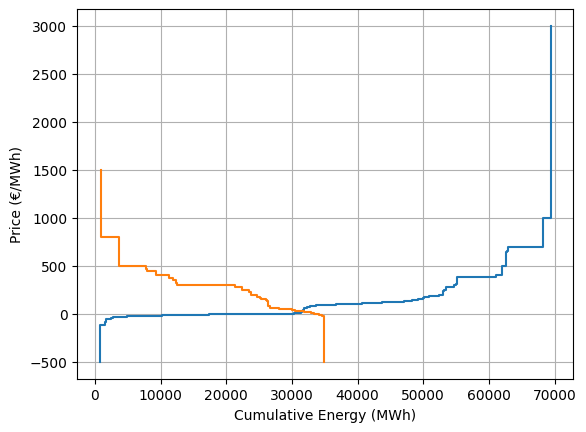

In [5]:
import matplotlib.pyplot as plt

plt.step(supply_curve["CumEnergy"], supply_curve["Price"], where="post")
plt.step(demand_curve["CumEnergy"], demand_curve["Price"], where="post")
plt.xlabel("Cumulative Energy (MWh)")
plt.ylabel("Price (€/MWh)")
plt.grid(True)
plt.show()

In [6]:
# Examples of supply and demand curves
date=pd.Timestamp('2025-10-01')

hour=12

side = 'V'  # Venta (supply)
supply_curve = curves_all[(date, hour, side)]

side='C' # Compra (demand)
demand_curve = curves_all[(date, hour, side)]

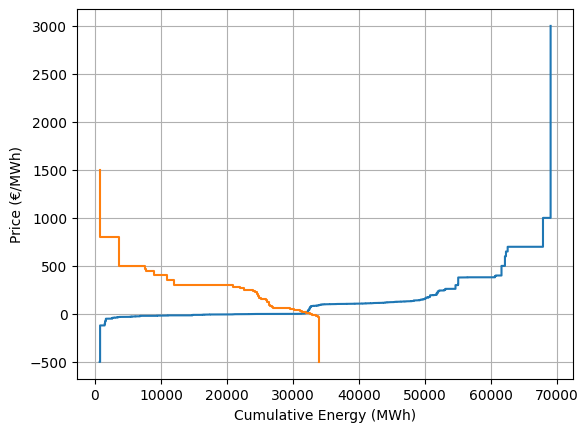

In [7]:
plt.step(supply_curve["CumEnergy"], supply_curve["Price"], where="post")
plt.step(demand_curve["CumEnergy"], demand_curve["Price"], where="post")
plt.xlabel("Cumulative Energy (MWh)")
plt.ylabel("Price (€/MWh)")
plt.grid(True)
plt.show()

In [8]:
import joblib

joblib.dump(curves_all, "offered_curves_dict.joblib")

['offered_curves_dict.joblib']